Import Libraries & Filling Numerical Values

In [5]:
import pandas as pd
import numpy as np


df = pd.read_excel(r'C:\Users\Husnain\PycharmProjects\JupyterProject\Family Income and Expenditure.xlsx')


df = df.fillna(df.mean(numeric_only=True))

df

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41539,119773,XII - SOCCSKSARGEN,44875,Enterpreneurial Activities,1,23675,21542,1476,6120,1632,...,0,0,0,0,0,1,0,0,0,0
41540,137320,XII - SOCCSKSARGEN,31157,Enterpreneurial Activities,1,2691,1273,1886,4386,1840,...,0,0,0,0,0,3,0,0,0,0
41541,133171,XII - SOCCSKSARGEN,45882,Enterpreneurial Activities,2,28646,27339,480,4796,1232,...,0,0,0,0,0,1,0,0,0,0
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0


Z-Score Scaling

In [6]:
X = df.drop('Total Household Income', axis=1)
y = df['Total Household Income']

numeric_cols = X.select_dtypes(include='number').columns

X[numeric_cols] = (X[numeric_cols] - X[numeric_cols].mean()) / X[numeric_cols].std()

print("Step 2 Complete: Numerical columns scaled.")

Step 2 Complete: Numerical columns scaled.


Label Encoding

In [7]:
from sklearn.preprocessing import LabelEncoder
label_cols = [
    'Household Head Highest Grade Completed',
    'Type of Roof',
    'Type of Walls'
]

le = LabelEncoder()

for col in label_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

X[label_cols].head()



,Household Head Highest Grade Completed,Type of Roof,Type of Walls
0,41,6,4
1,44,6,4
2,16,0,0
3,6,0,0
4,6,0,2


One Hot Encoding

In [9]:
nominal_cols = [
    'Region',
    'Main Source of Income',
    'Agricultural Household indicator',
    'Household Head Sex',
    'Household Head Marital Status',
    'Household Head Job or Business Indicator',
    'Household Head Occupation',
    'Household Head Class of Worker',
    'Type of Household',
    'Type of Building/House',
    'Tenure Status',
    'Toilet Facilities',
    'Electricity',
    'Main Source of Water Supply'
]


X_encoded = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

print("Step 3 Complete: Encoding successful.")
print(f"Shape before: {X.shape}")
print(f"Shape after: {X_encoded.shape}")

# Show the result
X_encoded.head()

Step 3 Complete: Encoding successful.
Shape before: (41544, 59)
Shape after: (41544, 486)


,Total Food Expenditure,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,Vegetables Expenditure,Restaurant and hotels Expenditure,Alcoholic Beverages Expenditure,Tobacco Expenditure,...,"Main Source of Water Supply_Lake, river, rain and others",Main Source of Water Supply_Others,"Main Source of Water Supply_Own use, faucet, community water system","Main Source of Water Supply_Own use, tubed/piped deep well",Main Source of Water Supply_Peddler,"Main Source of Water Supply_Protected spring, river, stream, etc","Main Source of Water Supply_Shared, faucet, community water system","Main Source of Water Supply_Shared, tubed/piped deep well",Main Source of Water Supply_Tubed/piped shallow well,"Main Source of Water Supply_Unprotected spring, river, stream, etc"
0,0.634201,1.262860,1.714317,1.346570,0.803446,0.260805,2.561404,-0.524635,-0.499012,-0.573831,...,False,False,True,False,False,False,False,False,False,False
1,-0.335667,-0.579567,-0.442374,0.656707,0.069594,-0.173575,0.856343,-0.551633,-0.057518,-0.040694,...,False,False,True,False,False,False,False,False,False,False
2,-0.454901,0.671911,1.177190,-0.262635,-1.016272,-0.276277,-0.367229,-0.459459,-0.374842,0.557709,...,False,False,False,False,False,False,True,False,False,False
3,-0.133819,0.660624,0.892212,0.035620,0.036185,-0.626475,0.872706,-0.386268,-0.278265,-0.573831,...,False,False,True,False,False,False,False,False,False,False
4,0.184474,0.719288,1.020802,0.747869,0.099803,-0.389081,1.894773,-0.381206,-0.020726,-0.573831,...,False,False,True,False,False,False,False,False,False,False


Applying PCA, Training, Cross Validation KFold

In [10]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

pipeline = Pipeline([
    ('pca', PCA(n_components=0.95)),
    ('model', model)
])

scores = cross_val_score(
    pipeline,
    X_encoded,
    y,
    cv=kf,
    scoring='r2'
)


print(f"Individual Fold Scores (R^2): {scores}")
print(f"Average Accuracy (R^2): {scores.mean():.4f}")


Individual Fold Scores (R^2): [0.85286756 0.82668548 0.75504755 0.83436777 0.80935131]
Average Accuracy (R^2): 0.8157


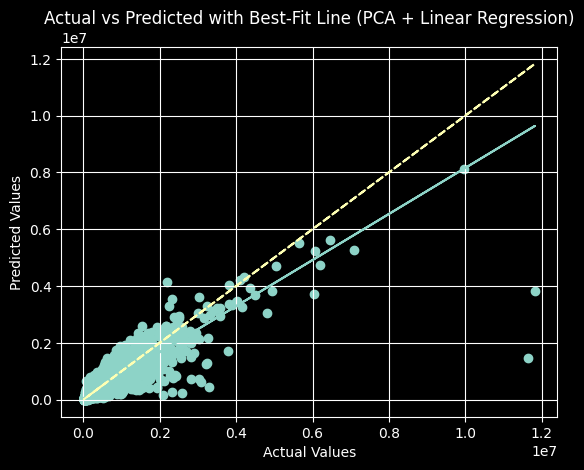

In [12]:
from sklearn.model_selection import  cross_val_predict
import matplotlib.pyplot as plt
y_pred = cross_val_predict(
    pipeline,
    X_encoded,
    y,
    cv=kf
)


plt.figure()


plt.scatter(y, y_pred)


m, b = np.polyfit(y, y_pred, 1)
plt.plot(y, m*y + b)

plt.plot(y, y, linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Best-Fit Line (PCA + Linear Regression)")
plt.grid(True)
plt.show()
